In [40]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import DenseNet121
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier

In [42]:
DATA = "./taiwan/data augmentation"
CLASS = ["Bacterial spot", "Black mold", "Gray spot", "health", "Late blight", "powdery mildew"]
BATCH_SIZE = 16
TRAIN_DIR = DATA+"/Train"
TEST_DIR = DATA+"/Test"

In [43]:
datagenerator = ImageDataGenerator(rescale=1.0 / 255.0)
train = datagenerator.flow_from_directory(
    TRAIN_DIR, 
    target_size=(224,224), 
    batch_size=BATCH_SIZE, 
    class_mode='categorical', 
    classes= CLASS,  
    shuffle=False
)
test = datagenerator.flow_from_directory(
    TEST_DIR, 
    target_size=(224,224), 
    batch_size=BATCH_SIZE, 
    class_mode='categorical', 
    classes=CLASS, 
    shuffle=False
)

Found 6282 images belonging to 6 classes.
Found 998 images belonging to 6 classes.


In [46]:
base_model = DenseNet121(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
x = GlobalAveragePooling2D()(base_model.output)
model = Model(inputs=base_model.input, outputs=x)

In [49]:
trainFeatures=model.predict(train, verbose =1)
trainLabels = train.classes

393/393 [==============================] - 33s 84ms/step


In [50]:
testFeatures=model.predict(test,verbose=1)
testLabels = test.classes

63/63 [==============================] - 5s 83ms/step


In [55]:
def performace_measure(model, testData, testLabel, model_name):
    predictedLabel = model.predict(testData)
    accuracy = accuracy_score(testLabel, predictedLabel)
    precision = precision_score(testLabel, predictedLabel, average= "weighted")
    recall = recall_score(testLabel, predictedLabel, average= "weighted")
    f1 = f1_score(testLabel, predictedLabel, average= "weighted")
    print(model_name)
    print(f"Accuracy: {accuracy*100}")
    print(f"Precision: {precision*100}")
    print(f"Recall: {recall*100}")
    print(f"F1 Score: {f1*100}")
    confustion_matrix = confusion_matrix(testLabel, predictedLabel)
    disp = ConfusionMatrixDisplay(confusion_matrix=confustion_matrix, display_labels=CLASS)
    fig, ax = plt.subplots(figsize=(10, 8))  
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
    plt.title(f"Confusion Matrix of {model_name}")
    plt.show()

K-Nearest Neighbour Classifier
Accuracy: 98.69739478957916
Precision: 98.71782769830291
Recall: 98.69739478957916
F1 Score: 98.69984170294173


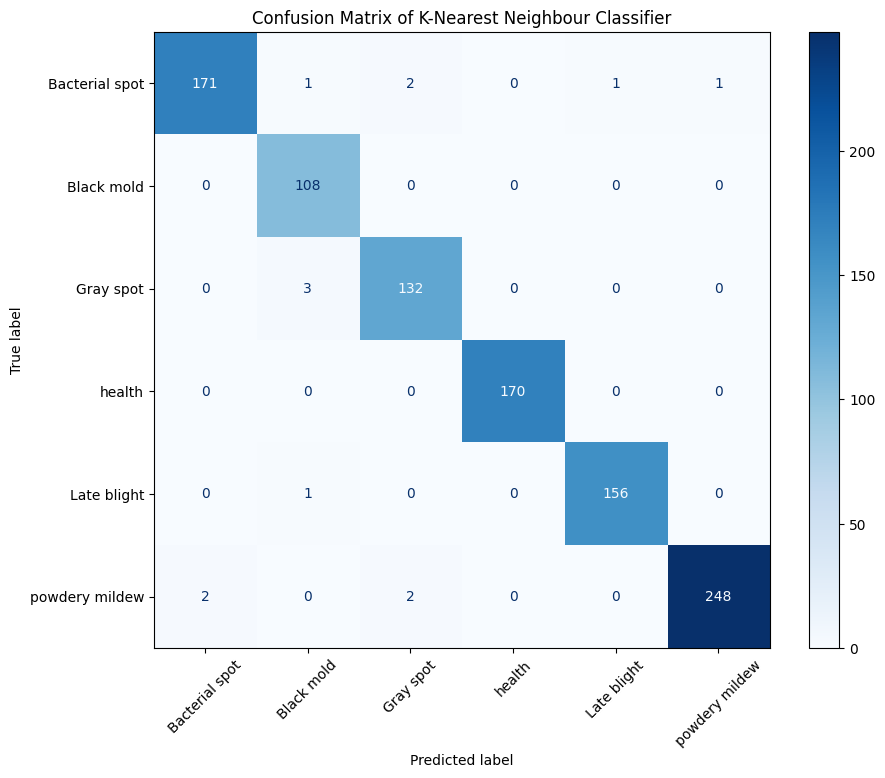

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(trainFeatures, trainLabels)
performace_measure(knn, testFeatures, testLabels, "K-Nearest Neighbour Classifier")

Random Forest Classifier
Accuracy: 96.59318637274549
Precision: 96.63710919130578
Recall: 96.59318637274549
F1 Score: 96.59439733247261


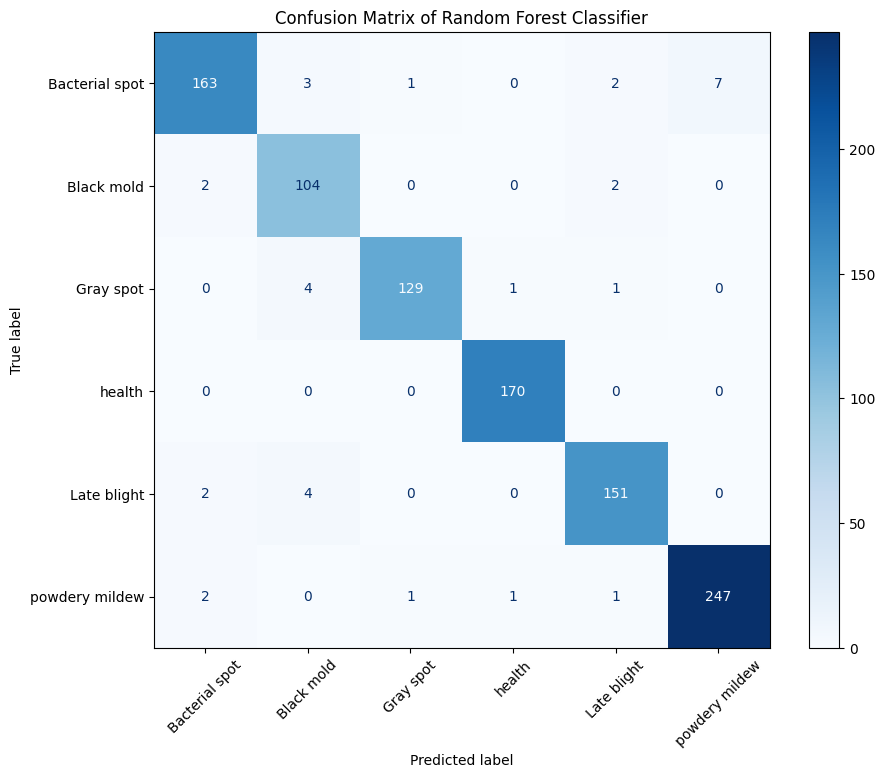

In [ ]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(trainFeatures, trainLabels)
performace_measure(rf, testFeatures, testLabels, "Random Forest Classifier")

Multiple Perceptron Classifier
Accuracy: 98.19639278557113
Precision: 98.21078117846834
Recall: 98.19639278557113
F1 Score: 98.19464405980504


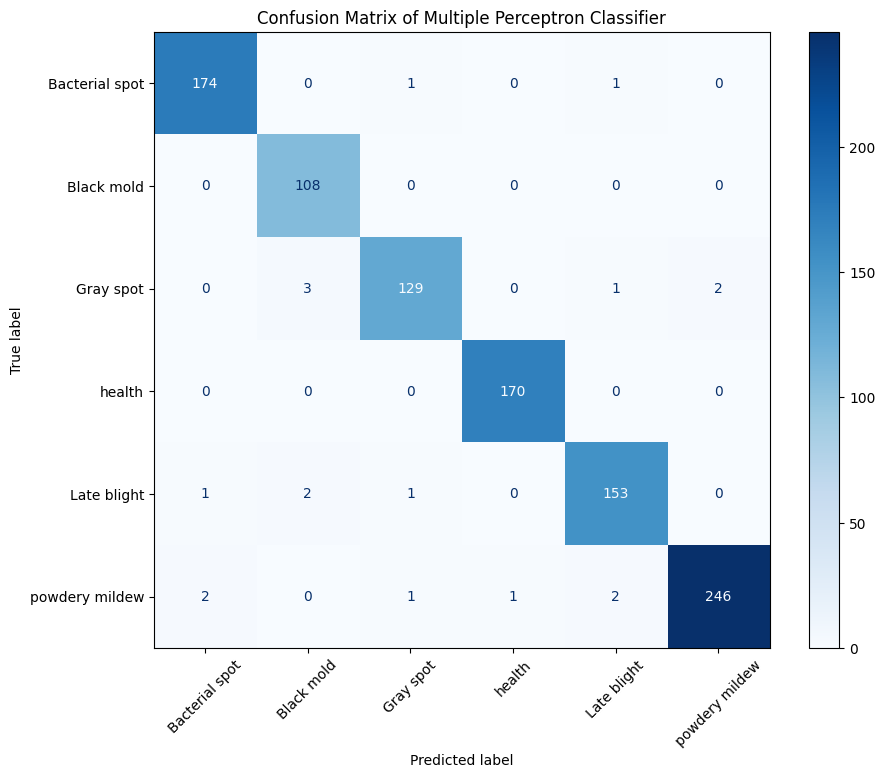

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(256, 64), max_iter=1000)
mlp.fit(trainFeatures, trainLabels)
performace_measure(mlp, testFeatures, testLabels, "Multiple Perceptron Classifier")

c:\Users\Antik\.conda\envs\py310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.113577 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 261120
[LightGBM] [Info] Number of data points in the train set: 6282, number of used features: 1024
[LightGBM] [Info] Start training from score -1.757030
[LightGBM] [Info] Start training from score -1.804254
[LightGBM] [Info] Start training from score -1.804254
[LightGBM] [Info] Start training from score -1.833696
[LightGBM] [Info] Start training from score -1.759802
[LightGBM] [Info] Start training from score -1.793672


c:\Users\Antik\.conda\envs\py310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Light Gradient Boosting Classifier
Accuracy: 97.89579158316634
Precision: 97.91431812864478
Recall: 97.89579158316634
F1 Score: 97.89693213921962


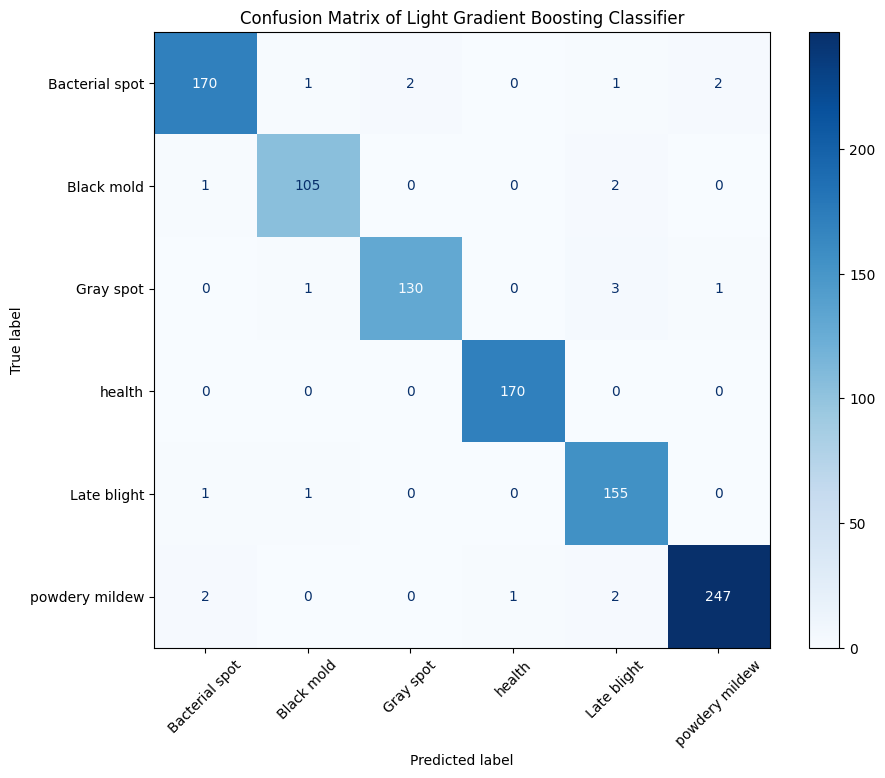

In [ ]:
lgbm = LGBMClassifier(n_estimators=100, learning_rate=0.1)
lgbm.fit(trainFeatures, trainLabels)
performace_measure(lgbm, testFeatures, testLabels, "Light Gradient Boosting Classifier")

Support Vector Machine Classifier
Accuracy: 96.4929859719439
Precision: 96.5081696864204
Recall: 96.4929859719439
F1 Score: 96.4800282662596


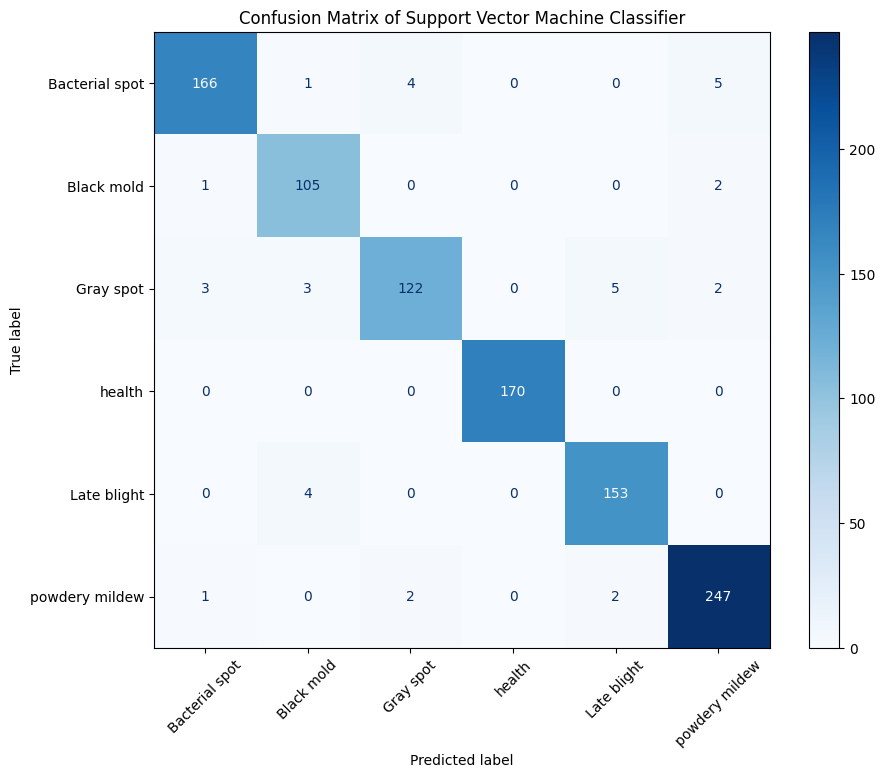

In [ ]:
svm = SVC(kernel='rbf', probability=True)  
svm.fit(trainFeatures, trainLabels)
performace_measure(svm, testFeatures, testLabels, "Support Vector Machine Classifier")

c:\Users\Antik\.conda\envs\py310\lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
c:\Users\Antik\.conda\envs\py310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.074683 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 261120
[LightGBM] [Info] Number of data points in the train set: 6282, number of used features: 1024
[LightGBM] [Info] Start training from score -1.757030
[LightGBM] [Info] Start training from score -1.804254
[LightGBM] [Info] Start training from score -1.804254
[LightGBM] [Info] Start training from score -1.833696
[LightGBM] [Info] Start training from score -1.759802
[LightGBM] [Info] Start training from score -1.793672


c:\Users\Antik\.conda\envs\py310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Ensemble Voting Classifier
Accuracy: 99.49899799599199
Precision: 99.49992152611702
Recall: 99.49899799599199
F1 Score: 99.49887091609867


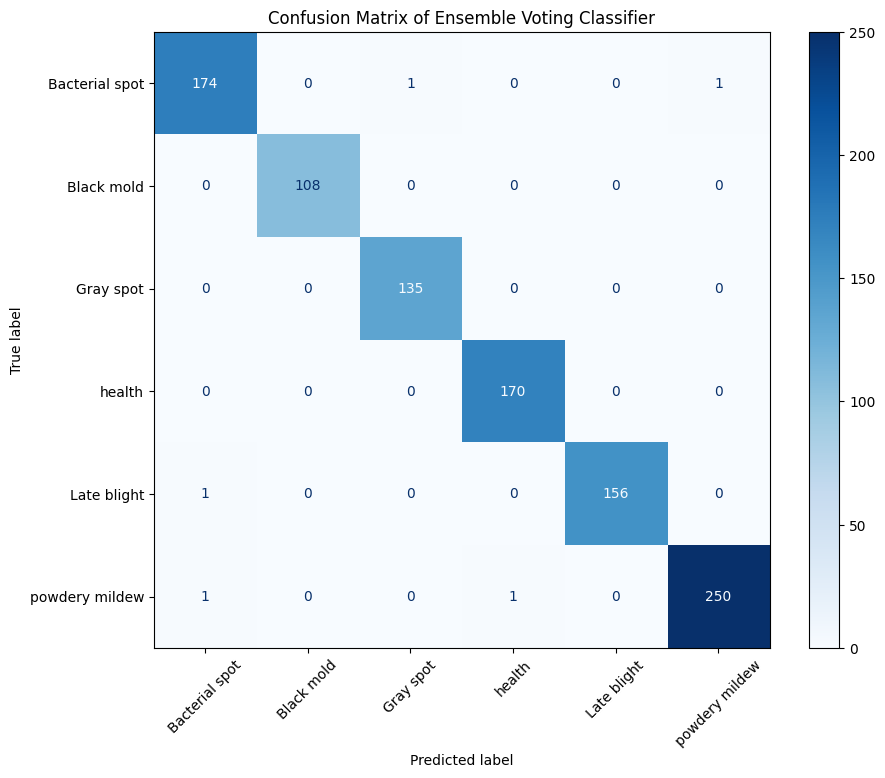

In [61]:
voting = VotingClassifier(estimators=[
    ('knn', knn),
    ('svm', svm),
    ('mlp', mlp),
    ('lgbm', lgbm),
    ('rf', rf),
], voting='soft')

voting.fit(trainFeatures, trainLabels)
performace_measure(voting, testFeatures, testLabels, "Ensemble Voting Classifier")